In [1]:
#imports
import os
import sys
import random
from pathlib import Path
from shutil import copyfile
import multiprocessing as mp
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib as mpl
from tqdm import tqdm


import numpy as  np
from astropy.io import fits
import pandas as pd

import pypeit
from pypeit.metadata import PypeItMetaData
from pypeit.spectrographs.util import load_spectrograph
from pypeit import spec2dobj, specobjs

from sklearn.preprocessing import MinMaxScaler

In [2]:
plt.rcParams.update({
    "figure.figsize": (8, 5),  # Default figure size
    "axes.titlesize": 16,      # Title font size
    "axes.labelsize": 14,      # Axis label font size
    "xtick.labelsize": 12,     # X-tick label font size
    "ytick.labelsize": 12,     # Y-tick label font size
    "legend.fontsize": 12,     # Legend font size
    "lines.linewidth": 2,      # Line width
    "grid.alpha": 0.5,         # Grid transparency
    "grid.linestyle": "--",    # Grid line style
    "axes.grid": True,         # Show grid
    "axes.facecolor": "#F6F5F3", # Axes background color
    "savefig.dpi": 300,        # Default DPI for saving figures
    "text.usetex": True,       # Use LaTeX for text rendering
    "font.family": "serif",    # Use serif fonts
})

cs = ["#335c67","#fff3b0","#e09f3e","#9e2a2b","#540b0e", "#b3b3cc"] # Color palette for plots

## **Load the Data**

In [3]:
source_df = pd.read_csv('M71_xmatch_sources.csv')


#apogee
allstar = pd.read_hdf('/geir_data/scr/nwolfish/DATA/apogee_dr17.h5', key = 'allstar')
allstar['APOGEE_ID'] = allstar['APOGEE_ID'].str.decode('utf-8') #decoding
allstar['FIELD'] = allstar['FIELD'].str.decode('utf-8') #decoding
allstar.drop(index=11215, inplace=True)
allstar.reset_index(drop=True, inplace=True)

idxs = allstar.loc[allstar['APOGEE_ID'].isin(source_df['apogee_id'])].index
apogee_spectra = pd.read_pickle('/geir_data/scr/nwolfish/DATA/apogee_spectra.pkl')
#apspec_M71 = apogee_spectra.loc[idxs]

In [4]:
allstar[['FILE', 'TEFF', 'LOGG', 'FE_H'] + [col for col in allstar.columns if '_FE' in col]]

,FILE,TEFF,LOGG,FE_H,C_FE,C_FE_ERR,N_FE,N_FE_ERR,O_FE,O_FE_ERR,...,CR_FE,CR_FE_ERR,MN_FE,MN_FE_ERR,CO_FE,CO_FE_ERR,NI_FE,NI_FE_ERR,CE_FE,CE_FE_ERR
0,b'apStar-dr17-2M00000546+6152107.fits',4073.770020,1.281504,-0.283400,-0.074204,0.010235,0.246520,0.012232,0.098487,0.009803,...,-0.014336,0.028630,0.041342,0.014474,0.098550,0.029541,0.008642,0.011708,0.055960,0.033516
1,b'apStar-dr17-2M00001653+5540107.fits',4148.143555,1.592674,-0.188000,0.120190,0.009904,0.241980,0.011950,0.248513,0.009778,...,-0.017456,0.027450,0.009712,0.013740,0.160740,0.029782,0.060632,0.011144,-0.162440,0.035609
2,b'apStar-dr17-2M00002005+5703467.fits',4350.929199,1.545981,-0.570470,-0.030053,0.014085,0.235320,0.016581,0.161593,0.013782,...,-0.084216,0.043105,-0.076928,0.018134,0.057580,0.045662,0.032082,0.014396,-0.110070,0.044994
3,b'apStar-dr17-2M00002118+6136420.fits',4223.811523,1.570289,-0.284620,-0.006798,0.010828,0.214240,0.013046,0.133858,0.010750,...,-0.035436,0.031030,0.014332,0.014730,0.155250,0.033804,0.038803,0.011880,-0.033440,0.038641
4,b'apStar-dr17-2M00003414+7539100.fits',4072.603271,1.628189,0.104890,-0.032821,0.008051,0.188550,0.009761,0.054485,0.008125,...,-0.033092,0.020226,0.091212,0.011192,0.079120,0.023021,-0.021175,0.009215,-0.058480,0.032098
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19794,b'apStar-dr17-2M23592095+6248015.fits',4079.163330,0.933848,-0.515570,-0.188850,0.012001,0.305500,0.014137,0.066274,0.011057,...,0.001824,0.035588,0.002672,0.016981,0.014620,0.034614,-0.003548,0.013584,0.093740,0.034578
19795,b'apStar-dr17-2M23592335+6119074.fits',4173.192383,1.484951,-0.256350,-0.065301,0.010425,0.257790,0.012552,0.075278,0.010255,...,-0.021726,0.029476,0.026682,0.014383,0.080910,0.031746,0.016703,0.011626,-0.039840,0.036722
19796,b'apStar-dr17-2M23594955+1529189.fits',4376.455078,1.689413,-0.433450,-0.074328,0.012805,0.256000,0.015304,0.135509,0.013015,...,0.023334,0.038243,-0.060228,0.016476,0.121710,0.042466,0.055873,0.013162,-0.000760,0.045355
19797,b'apStar-dr17-2M23595606+6251121.fits',4291.005859,1.823921,-0.099785,-0.040156,0.009735,0.222441,0.011923,0.079641,0.010186,...,0.008673,0.026923,0.048877,0.013011,0.119452,0.031611,0.026607,0.010575,0.031129,0.040303


## **Check StarCLIP Limitations**

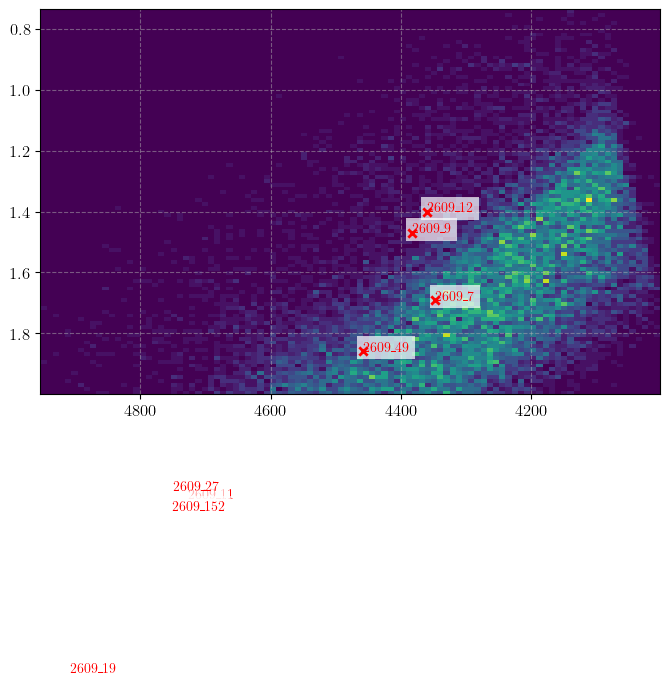

In [5]:
fig, ax = plt.subplots()
plt.hist2d(allstar['TEFF'], allstar['LOGG'], bins = 100)
[plt.text(source_df.loc[i, 'teff'], source_df.loc[i, 'logg'], source_df.loc[i, 'source_name'], color = 'red', bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")) for i in range(len(source_df))]
plt.scatter(source_df['teff'], source_df['logg'], c = 'red', marker = 'x', zorder = 11)

ax.invert_yaxis()
ax.invert_xaxis()
plt.show()

In [6]:
#clip
max_teff = max(allstar['TEFF'])
min_teff = min(allstar['TEFF'])

max_logg = max(allstar['LOGG'])
min_logg = min(allstar['LOGG'])

sources_in_cut = source_df.loc[(source_df['teff'] < max_teff) & (source_df['teff'] > min_teff)]
sources_in_cut = sources_in_cut.loc[(sources_in_cut['logg'] < max_logg) & (sources_in_cut['logg'] > min_logg)]
sources_in_cut.reset_index(inplace = True)

In [7]:
idxs = allstar.loc[allstar['APOGEE_ID'].isin(sources_in_cut['apogee_id'])].index

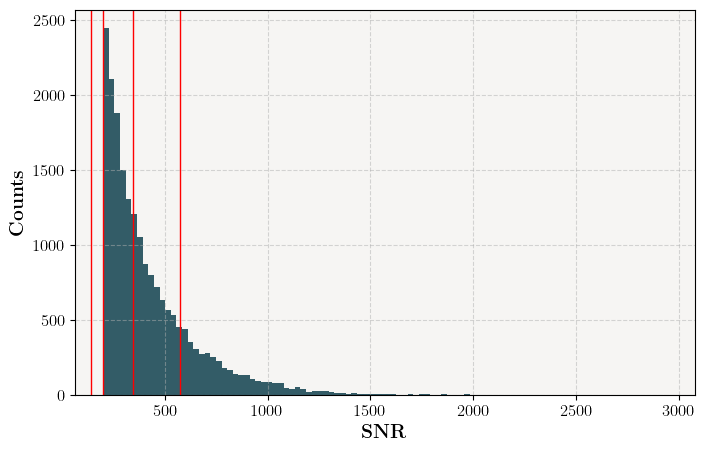

In [8]:
#is snr my issue?

plt.hist(allstar['SNR'], bins = 100, color = cs[0])
[plt.axvline(snr, color = 'red', linewidth = 1) for snr in sources_in_cut['snr']]
plt.xlabel(r'\textbf{SNR}')
plt.ylabel(r'\textbf{Counts}')
plt.show()

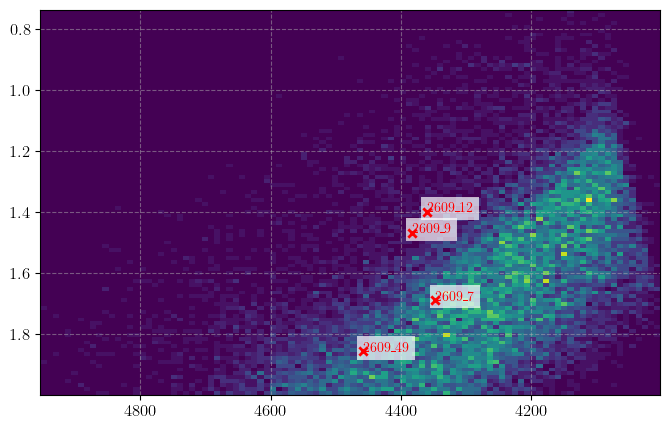

In [9]:
# Replot
fig, ax = plt.subplots()
plt.hist2d(allstar['TEFF'], allstar['LOGG'], bins = 100)
[plt.text(sources_in_cut.loc[i, 'teff'], sources_in_cut.loc[i, 'logg'], sources_in_cut.loc[i, 'source_name'], color = 'red', bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")) for i in range(len(sources_in_cut))]
plt.scatter(source_df['teff'], source_df['logg'], c = 'red', marker = 'x', zorder = 11)

ax.invert_yaxis()
ax.invert_xaxis()
plt.show()

## **Find Closest Matches**

In [10]:
#columns for euclid distance
dist_cols = ['teff', 'logg'] + [col for col in sources_in_cut.columns if '_fe' in col or '_h' in col]
dist_measure_jwst = sources_in_cut[dist_cols]
dist_measure_jwst.columns = [col.upper() for col in dist_cols]
dist_cols = [col.upper() for col in dist_cols]

In [11]:
distances = pd.DataFrame(
)
for i, star in dist_measure_jwst.iterrows():
    distance =  ((star - allstar[dist_cols])**2).sum(axis=1)
    distances['{}'.format(sources_in_cut.loc[i, 'source_name'])] = distance

In [12]:
#find closest match
closest_matches = [(src, distances.loc[(min(distances[src]) == distances[src])].index[0]) for src in sources_in_cut['source_name']]

In [13]:
match1 = closest_matches[3]


## **WL Grid**

In [14]:
## Load in JWST files ## 
LOCAL_DATA_DIR = Path('/geir_data/scr/nwolfish/DATA')
jwst_spec_file = LOCAL_DATA_DIR / 'JWST_APOGEE.h5'
jwst_wave = pd.read_hdf(jwst_spec_file, 'wavelength').iloc[0].values
jwst_labels = pd.read_hdf(jwst_spec_file, 'labels')
jwst_spectra = pd.read_hdf(jwst_spec_file, 'spectra')
jwst_spectra.reset_index(drop=True, inplace=True)
jwst_labels.reset_index(drop=True, inplace=True) 

In [15]:
closest_matches

[('2609_7', np.int64(9005)),
 ('2609_9', np.int64(2189)),
 ('2609_12', np.int64(11455)),
 ('2609_49', np.int64(16958))]

In [88]:
## real JWST Data
REAL_DATA_DIR = Path('JWST_spec/exp_2')
exp_2_list = list(REAL_DATA_DIR.glob('*'))
match_f = [[fname for fname in exp_2_list if match[0] in fname.name] for match in closest_matches]

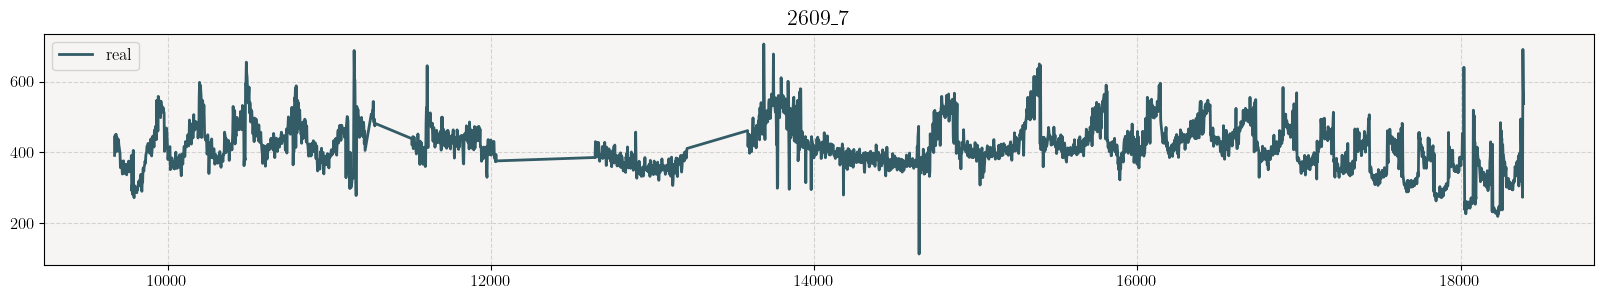

problem with ('2609_9', np.int64(2189))


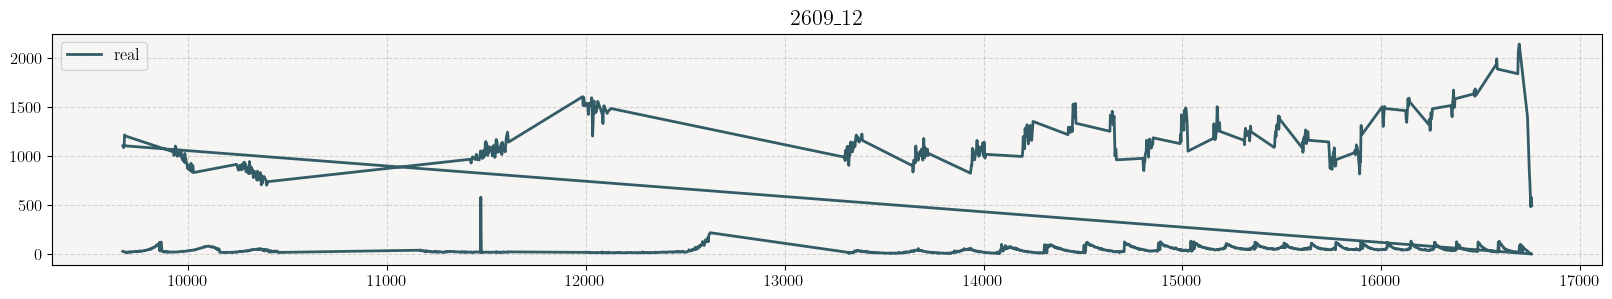

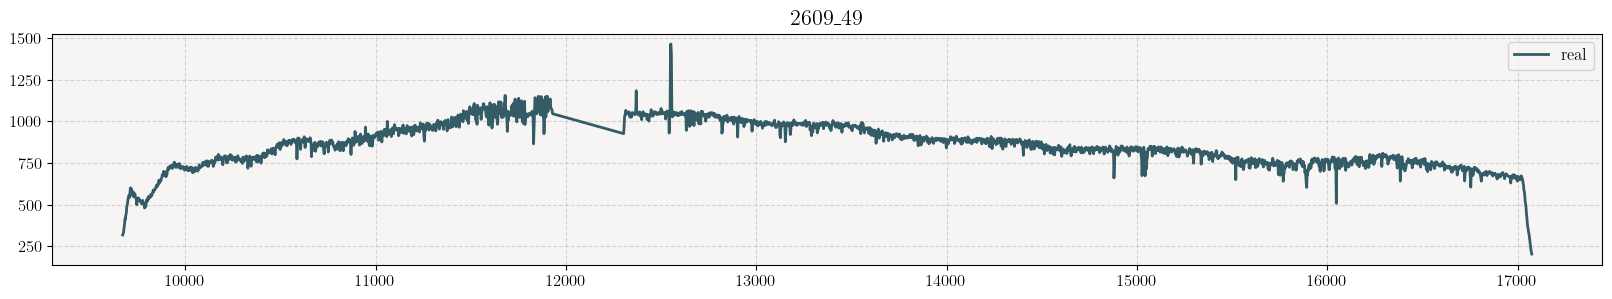

In [89]:
plot_path = Path('/geir_data/scr/nwolfish/M71/JWST_spec/plots')
plot_path.mkdir(exist_ok = True)

for i, match in enumerate(match_f):
    try:
        sobjs = specobjs.SpecObjs.from_fitsfile(match[0])
        plt.figure(figsize = (20, 3))
        plt.plot(sobjs['OPT_WAVE'][sobjs['OPT_MASK']], sobjs['OPT_COUNTS'][sobjs['OPT_MASK']], label = 'real', color = cs[0])
        plt.title(closest_matches[i][0])
        plt.savefig(plot_path / f'exp_2_{closest_matches[i][0]}.png')
        plt.legend()
        plt.show()
    except:
        print(f'problem with {closest_matches[i]}')

In [81]:
#LOAD REAL SPEC
spec_49 = match_f[-1][0]

sobjs = specobjs.SpecObjs.from_fitsfile(spec_49)

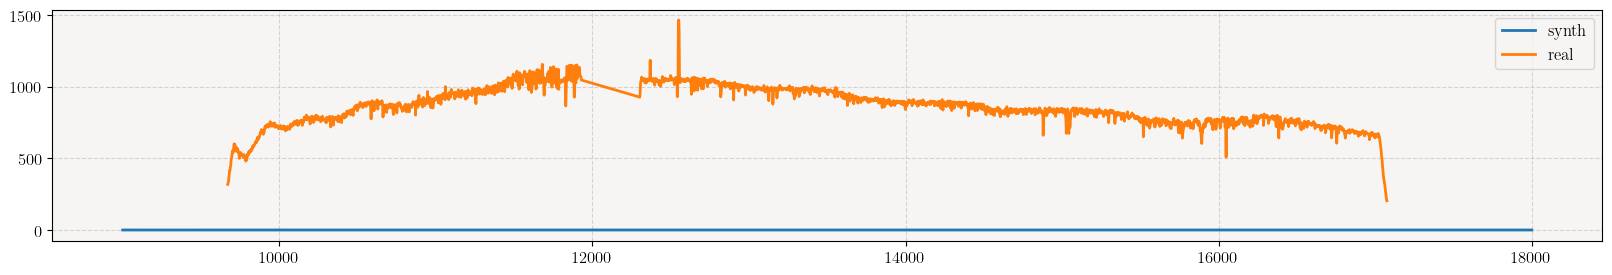

In [82]:
plt.figure(figsize = (20, 3))
plt.plot(jwst_spectra.columns, jwst_spectra.loc[match1[1]], label = 'synth')
plt.plot(sobjs['OPT_WAVE'][sobjs['OPT_MASK']], sobjs['OPT_COUNTS'][sobjs['OPT_MASK']], label = 'real')
plt.legend()
plt.show()

In [83]:
synth_grid = jwst_spectra.columns
real_grid = sobjs['OPT_WAVE'][sobjs['OPT_MASK']]

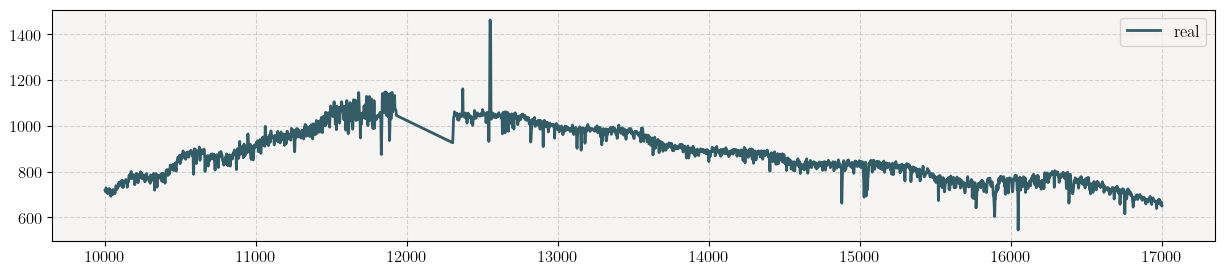

In [84]:
from scipy.interpolate import interp1d

cuts = [10000, 17000]
# 1. Define a common grid
x_common = synth_grid[(synth_grid >= cuts[0]) & (synth_grid <= cuts[1])]

# 2. Interpolators
f_synth = interp1d(synth_grid, jwst_spectra.loc[match1[1]], kind='next', fill_value=0)
f_real  = interp1d(real_grid,  sobjs['OPT_COUNTS'][sobjs['OPT_MASK']],  kind='linear', bounds_error = False, fill_value=1)

# 3. Interpolated signals
y_synth_interp = f_synth(x_common)
y_real_interp  = f_real(x_common)

# 4. Plot
plt.figure(figsize=(15, 3))
# plt.plot(x_common, y_synth_interp, label="synth")
plt.plot(x_common, y_real_interp, label="real", color = cs[0])
plt.legend()
plt.show()

## **Normalize**

In [85]:
# normalize
real_scaler = MinMaxScaler()
y_real_scaled = real_scaler.fit_transform(y_real_interp.reshape(-1, 1))

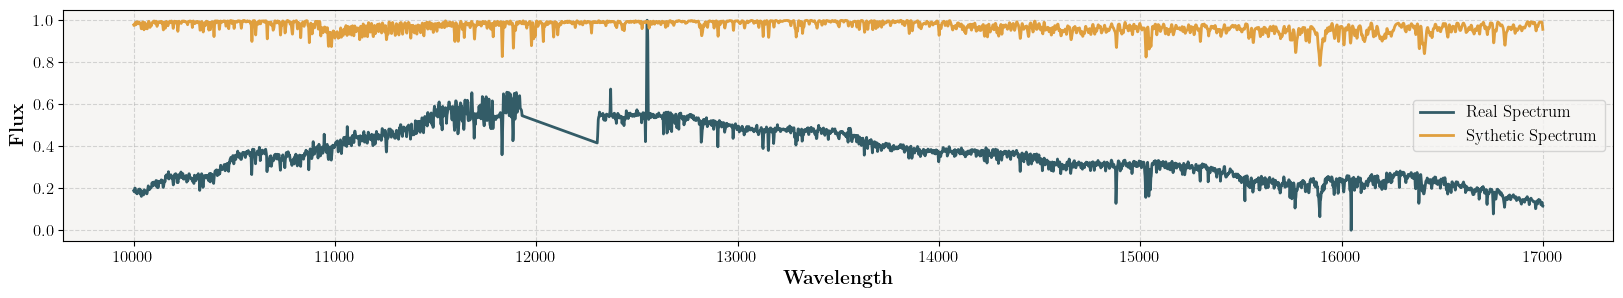

In [86]:
plt.figure(figsize = (20, 3))
plt.plot(x_common, y_real_scaled[:, 0], label = 'Real Spectrum', color = cs[0])
plt.plot(x_common, y_synth_interp, label = 'Sythetic Spectrum', color = cs[2])
plt.xlabel(r'\textbf{Wavelength}')
plt.ylabel(r'\textbf{Flux}')
plt.legend()

## **Rest Frame Correction**

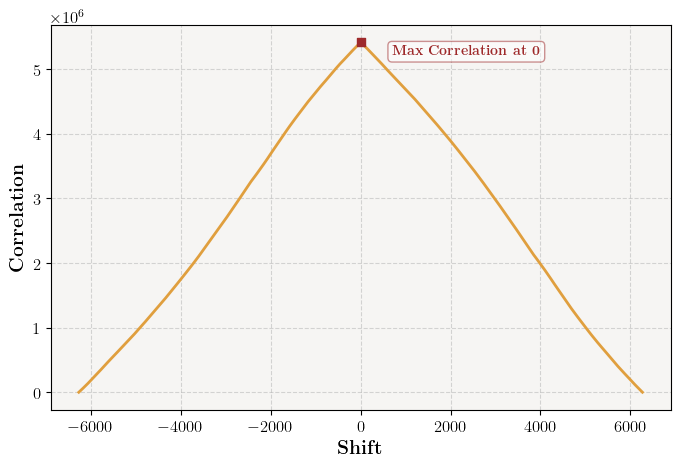

In [87]:
corr = np.correlate(y_synth_interp, y_real_interp, mode = 'full')
lags = np.arange(-len(y_real_interp)+1, len(y_synth_interp))

plt.figure(dpi = 100)
plt.plot(lags, corr, color = cs[2])
plt.scatter(lags[corr == max(corr)], max(corr), zorder = 10, color = cs[3], marker = 's')
plt.text(lags[corr == max(corr)]+ 700, max(corr) - 0.2e6, fr'\textbf{{Max Correlation at {lags[corr == max(corr)][0]}}}', color = cs[3], bbox = {'boxstyle': 'round', 'facecolor': 'white', 'alpha': 0.5, 'edgecolor': cs[3]})
plt.xlabel(r'\textbf{Shift}')
plt.ylabel(r'\textbf{Correlation}')
plt.show()